INFORMATION

In [ ]:
#Dataset information
#Directory: cd /home/ws/ugoby/.cache/kagglehub/datasets/jefmenegazzo/pvs-passive-vehicular-sensors-datasets/versions/2

#Example PVS1-9:
#(master_thesis) ugoby@aifb-sydsen-sun:~/.cache/kagglehub/datasets/jefmenegazzo/pvs-passive-vehicular-sensors-datasets/versions/2$ ls
#'PVS 1'  'PVS 2'  'PVS 3'  'PVS 4'  'PVS 5'  'PVS 6'  'PVS 7'  'PVS 8'  'PVS 9'

#Example PVS1:
#(master_thesis) ugoby@aifb-sydsen-sun:~/.cache/kagglehub/datasets/jefmenegazzo/pvs-passive-vehicular-sensors-datasets/versions/2/PVS 1$ ls
#dataset_gps.csv           dataset_gps_mpu_right.csv  dataset_mpu_left.csv   dataset_settings_left.csv   map.html                video_dataset_right.mp4  video_environment_dataset_left.mp4
#dataset_gps_mpu_left.csv  dataset_labels.csv         dataset_mpu_right.csv  dataset_settings_right.csv  video_dataset_left.mp4  video_environment.mp4    video_environment_dataset_right.mp4



#This file helps build the spectrogram dataset and time sync it with the labels. It also helps to build the dataset for the video frames and time sync it with the labels. The dataset is built for each PVS1-9 and then merged together.


TEST LOADER TEST AND VISUALIZATION


📊 Class distribution in test_loader:
  Class 0: 3612
  Class 1: 2511
  Class 2: 2744
Total samples: 8867

Class mapping: {'asphalt': 0, 'dirt': 1, 'cobblestone': 2}

🔍 Sample 42: Label dirt (1)


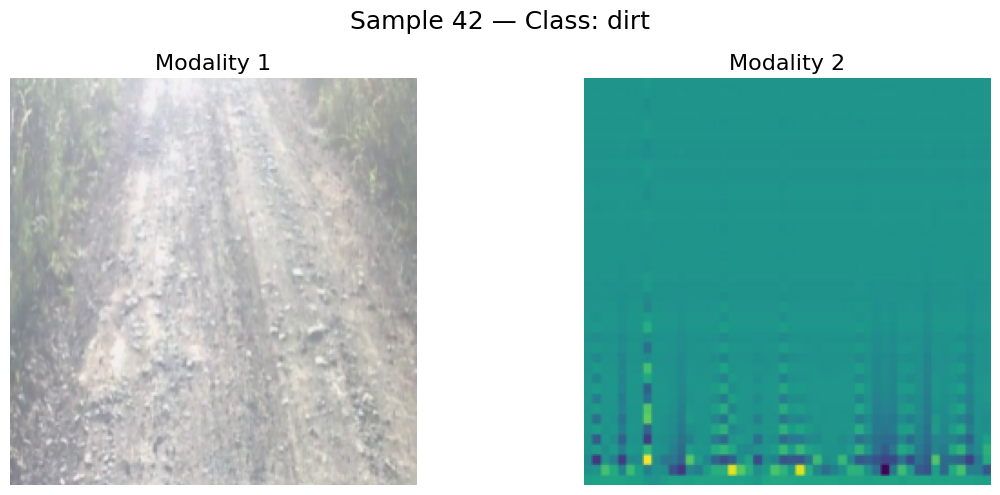

In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from data_loaders import multi_pvs_multimodal_loader

# === CONFIG ===
image_root = "/home/ws/ugoby/master_thesis/data_conference/video"
sensor_root = "/home/ws/ugoby/master_thesis/data_conference/mfcc"
batch_size, resize, num_classes = 32, (224, 224), 3
sample_index = 42

# === LOAD TEST LOADER ===
result = multi_pvs_multimodal_loader(
    image_root=image_root,
    sensor_root=sensor_root,
    batch_size=batch_size,
    resize=resize,
    return_class_map=True,
    num_classes=num_classes,
)

# --- Flexible unpacking ---
train_loader, val_loader, test_loader, *extra = result if len(result) >= 3 else (*result, None)
class_map = extra[0] if extra else None

# === GET ALL LABELS (vectorized) ===
all_labels = torch.cat([batch[-1] for batch in test_loader]).cpu().numpy()
class_counts = Counter(all_labels)

print("\n📊 Class distribution in test_loader:")
[print(f"  Class {i}: {count}") for i, count in sorted(class_counts.items())]
print(f"Total samples: {len(all_labels)}")

# === PRINT CLASS MAP ===
mapping = class_map or getattr(test_loader.dataset, "class_to_idx", None)
if mapping:
    print("\nClass mapping:", mapping)
    inv_map = {v: k for k, v in mapping.items()}
else:
    inv_map = {}

# === VISUALIZE SAMPLE ===
dataset = test_loader.dataset
sample = dataset[sample_index]
*modal_images, label = sample
label_name = inv_map.get(int(label), str(label))

print(f"\n🔍 Sample {sample_index}: Label {label_name} ({label})")

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, len(modal_images), figsize=(6 * len(modal_images), 5))
axes = np.atleast_1d(axes)

for i, (img, ax) in enumerate(zip(modal_images, axes)):
    if isinstance(img, torch.Tensor) and img.ndim == 3:
        ax.imshow(np.clip(img.permute(1, 2, 0).cpu(), 0, 1))
        ax.set_title(f"Modality {i+1}", fontsize=16)
    else:
        ax.text(0.5, 0.5, f"Non-image modality\nshape={getattr(img, 'shape', '?')}",
                ha="center", va="center")
    ax.axis("off")

plt.suptitle(f"Sample {sample_index} — Class: {label_name}", fontsize=18)
plt.tight_layout()
plt.show()


SYNCHRONIZE SENSOR AND IMAGE FILES LABELS

In [ ]:
#CAREFUL, renames a folder content to 00001_frame.jpg, 00002_frame.jpg, ...
import os
folder="/home/ws/ugoby/master_thesis/data_conferenceideo/PVS 4"
[os.rename(os.path.join(folder,f), os.path.join(folder, f"{i+1:05d}_frame.jpg")) for i,f in enumerate(sorted(os.listdir(folder))) if f.lower().endswith(('.jpg','.jpeg','.png'))]


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [25]:
import os
import pandas as pd
import random

def get_pvs_indices(pvs_number, mapping_csv="/home/ws/ugoby/master_thesis/data_conference/labels/index_mapping.csv"):
    """
    Loads image and sensor index mapping for a given PVS number.

    Parameters:
        pvs_number (int or str): The PVS dataset number (1–9).
        mapping_csv (str): Path to the mapping CSV file.

    Returns:
        tuple: (img_index_a, img_index_b, csv_index_a, csv_index_b)
    """
    if not os.path.exists(mapping_csv):
        raise FileNotFoundError(f"Mapping file not found: {mapping_csv}")

    df = pd.read_csv(mapping_csv)
    pvs_label = f"PVS{int(pvs_number)}"

    if pvs_label not in df["PVS"].values:
        raise ValueError(f"No mapping found for {pvs_label} in {mapping_csv}")

    row = df[df["PVS"] == pvs_label].iloc[0]
    img_a, img_b = int(row["img_index_a"]), int(row["img_index_b"])
    csv_a, csv_b = int(row["csv_index_a"]), int(row["csv_index_b"])

    print(f"✅ Loaded mapping for {pvs_label}:")
    print(f"  Image indices → A={img_a}, B={img_b}")
    print(f"  CSV indices   → A={csv_a}, B={csv_b}")

    return img_a, img_b, csv_a, csv_b


def compute_timeseries_image_relation(csv_path, image_folder, csv_index_a, img_index_a, csv_index_b, img_index_b):
    # Load CSV
    df = pd.read_csv(csv_path)
    csv_len = len(df)

    # Count images
    image_files = sorted([f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    img_len = len(image_files)
    if img_len == 0: raise ValueError("No image files found in the given folder.")
    if csv_len == 0: raise ValueError("CSV file is empty.")

    # Factor from A↔B
    csv_diff = csv_index_b - csv_index_a
    img_diff = img_index_b - img_index_a
    if csv_diff == 0 or img_diff == 0: raise ValueError("Invalid A/B points: indices are identical.")
    factor = csv_diff / img_diff  # CSV lines per image

    # Start/end estimation
    mid_csv = (csv_index_a + csv_index_b) / 2
    mid_img = (img_index_a + img_index_b) / 2
    csv_estimated_start = mid_csv - mid_img * factor
    csv_estimated_end   = mid_csv + (img_len - 1 - mid_img) * factor
    start_diff = csv_estimated_start
    end_diff   = csv_len - 1 - csv_estimated_end

    # Info
    print("=== Timeseries ↔ Image Relation ===")
    print(f"Total CSV lines: {csv_len}")
    print(f"Total images: {img_len}")
    print(f"Mapping factor (CSV lines per image frame): {factor:.6f}\n")
    print(f"Point A -> CSV index {csv_index_a} ↔ Image index {img_index_a}")
    print(f"Point B -> CSV index {csv_index_b} ↔ Image index {img_index_b}")
    print(f"Approximate overall CSV-to-image ratio: {csv_len / img_len:.6f}\n")
    print("=== Start/End Offset Estimation ===")
    if start_diff > 0:
        print(f"→ The CSV recording starts about {start_diff:.1f} lines earlier than the images.")
    else:
        print(f"→ The image sequence starts about {-start_diff:.1f} image-equivalent lines earlier than the CSV.")
    if end_diff > 0:
        print(f"→ The CSV recording ends about {end_diff:.1f} lines later than the images.")
    else:
        print(f"→ The image sequence ends about {-end_diff:.1f} image-equivalent lines later than the CSV.")

    # Trim CSV ONCE to the overlap window
    start_cut = max(int(round(csv_estimated_start)), 0)
    end_cut   = min(int(round(csv_estimated_end)), csv_len - 1)
    if start_cut >= end_cut: raise ValueError("Estimated alignment produced invalid start/end indices.")
    df_synced = df.iloc[start_cut:end_cut + 1].reset_index(drop=True)

    # Save trimmed
    output_dir = "/home/ws/ugoby/master_thesis/data_conference/labels/synced"
    os.makedirs(output_dir, exist_ok=True)
    base = os.path.basename(csv_path)
    base_no_ext = os.path.splitext(base)[0]
    output_path = os.path.join(output_dir, base_no_ext + "_synced.csv")
    df_synced.to_csv(output_path, index=False)

    # Summary
    new_len = len(df_synced)
    expected_csv_len = img_len * factor
    print("\n=== Synchronization Summary ===")
    print(f"Trimmed CSV saved to: {output_path}")
    print(f"Original CSV length: {csv_len}")
    print(f"Trimmed CSV length:  {new_len}")
    print(f"Expected aligned length (approx.): {expected_csv_len:.1f}")
    if abs(new_len - expected_csv_len) / max(expected_csv_len, 1) < 0.02:
        print("✅ The CSV and image recordings are now well aligned.")
    else:
        print("⚠️ Alignment mismatch still above tolerance (check manual points A and B).")

    # Return diffs so the assigner can SKIP frames when video starts/ends earlier
    return factor, df_synced, start_diff, end_diff


def assign_images_to_labels(df_synced, image_folder, factor, csv_path, start_diff=None, end_diff=None):
    """
    Assigns each image to a group of CSV lines using the provided factor (CSV lines per image),
    determines the majority class (asphalt, cobblestone, or dirt),
    and renames all image files accordingly.

    Steps:
      1. Resets all image filenames to 00001_frame.jpg, 00002_frame.jpg, ...
      2. Handles start/end misalignment (skips frames if video starts/ends earlier).
      3. Renames valid frames to 00001_asphalt.jpg etc., keeping correct numbering after skipped frames.
      4. Writes mapping into the CSV.
    """

    # === Step 1: Reset all image filenames ===
    image_files = sorted([f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    if len(image_files) == 0:
        raise ValueError("No image files found in the folder.")

    print(f"🔄 Resetting {len(image_files)} image filenames in '{image_folder}' ...")

    for i, f in enumerate(image_files):
        old_path = os.path.join(image_folder, f)
        new_path = os.path.join(image_folder, f"{i+1:05d}_frame.jpg")
        os.rename(old_path, new_path)

    # Reload and sort again after renaming
    image_files = sorted([f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    # === Step 2: Handle start/end misalignment ===
    img_len = len(image_files)
    csv_len = len(df_synced)
    print(f"Total CSV lines: {csv_len}")
    print(f"Total images: {img_len}")
    print(f"Mapping factor (CSV lines per image): {factor:.6f}")

    img_start_skip = int(round(max(0, -start_diff / factor))) if (start_diff is not None and start_diff < 0) else 0
    img_end_skip   = int(round(max(0, -end_diff   / factor))) if (end_diff   is not None and end_diff   < 0) else 0

    if img_start_skip > 0:
        print(f"Video starts earlier → skipping first {img_start_skip} frames.")
    if img_end_skip > 0:
        print(f"Video ends later → skipping last {img_end_skip} frames.")

    valid_images = image_files[img_start_skip: len(image_files) - img_end_skip if img_end_skip > 0 else None]
    print(f"Number of valid images to label: {len(valid_images)}")

    # === Step 3: Assign labels ===
    class_columns = ['asphalt_road', 'cobblestone_road', 'dirt_road']
    for col in class_columns:
        if col not in df_synced.columns:
            raise ValueError(f"Expected column '{col}' not found in the DataFrame.")

    image_filenames = []
    tie_count = 0

    # Offset numbering based on how many frames were skipped
    frame_offset = img_start_skip

    for j, img_name in enumerate(valid_images):
        start_idx = int(round(j * factor))
        end_idx   = int(round((j + 1) * factor))
        chunk = df_synced.iloc[start_idx:end_idx]

        if chunk.empty:
            continue

        sums = {cls: chunk[cls].sum() for cls in class_columns}
        max_val = max(sums.values())
        majority_classes = [cls for cls, v in sums.items() if v == max_val]

        if len(majority_classes) > 1:
            tie_count += 1
            chosen_class = random.choice(majority_classes)
        else:
            chosen_class = majority_classes[0]

        class_label = chosen_class.replace('_road', '')

        # Numbering starts AFTER skipped frames
        frame_number = frame_offset + j + 1
        new_filename = f"{frame_number:05d}_{class_label}.jpg"

        old_path = os.path.join(image_folder, img_name)
        new_path = os.path.join(image_folder, new_filename)
        os.rename(old_path, new_path)

        df_synced.loc[start_idx:end_idx - 1, 'image_filename'] = new_filename
        image_filenames.append(new_filename)

    df_synced['image_filename'] = df_synced['image_filename'].ffill().bfill()
    df_synced.to_csv(csv_path, index=False)

    # === Step 4: Summary ===
    print("\n=== Mapping Summary ===")
    print(f"Updated CSV saved to: {csv_path}")
    print(f"Labeled and renamed {len(image_filenames)} images in '{image_folder}'")
    print(f"Skipped {img_start_skip} at start, {img_end_skip} at end (unmatched frames).")
    print(f"Ties encountered: {tie_count}")
    print("✅ Image–CSV mapping completed successfully.\n")

    return df_synced

nr = "9"

# Example usage
img_a, img_b, csv_a, csv_b = get_pvs_indices(nr)
factor, df_synced, start_diff, end_diff = compute_timeseries_image_relation(
    csv_path=f"/home/ws/ugoby/master_thesis/data_conference/labels/synchronized_labels_mpu_left_PVS{nr}.csv",
    image_folder=f"/home/ws/ugoby/master_thesis/data_conference/video/PVS {nr}",
    img_index_a=img_a,
    img_index_b=img_b,
    csv_index_a=csv_a,
    csv_index_b=csv_b,
)

print("Step 1 done -- ")

df_mapped = assign_images_to_labels(
    df_synced=df_synced,
    image_folder=f"/home/ws/ugoby/master_thesis/data_conference/video/PVS {nr}",
    factor=factor,
    csv_path=f"/home/ws/ugoby/master_thesis/data_conference/labels/synced/synchronized_labels_mpu_left_PVS{nr}_synced.csv",
    start_diff=start_diff,
    end_diff=end_diff
)

print("Step 2 done -- ")

✅ Loaded mapping for PVS9:
  Image indices → A=2595, B=8484
  CSV indices   → A=17737, B=66072
=== Timeseries ↔ Image Relation ===
Total CSV lines: 91555
Total images: 10000
Mapping factor (CSV lines per image frame): 8.207675

Point A -> CSV index 17737 ↔ Image index 2595
Point B -> CSV index 66072 ↔ Image index 8484
Approximate overall CSV-to-image ratio: 9.155500

=== Start/End Offset Estimation ===
→ The image sequence starts about 3561.9 image-equivalent lines earlier than the CSV.
→ The CSV recording ends about 13047.4 lines later than the images.

=== Synchronization Summary ===
Trimmed CSV saved to: /home/ws/ugoby/master_thesis/data_conference/labels/synced/synchronized_labels_mpu_left_PVS9_synced.csv
Original CSV length: 91555
Trimmed CSV length:  78508
Expected aligned length (approx.): 82076.8
⚠️ Alignment mismatch still above tolerance (check manual points A and B).
Step 1 done -- 
🔄 Resetting 10000 image filenames in '/home/ws/ugoby/master_thesis/data_conference/video/PVS 

GENERATE MFCC FROM SYNCED LABELS


In [ ]:
from large_training import generate_all_pvs_mfcc

generate_all_pvs_mfcc(
    base_in_synced="/home/ws/ugoby/master_thesis/data_conference/labels/synced",
    base_in_degraded="/home/ws/ugoby/master_thesis/data_conference/labels/degraded",
    base_out_root_normal="/home/ws/ugoby/master_thesis/data_conference/mfcc",
    base_out_root_degraded="/home/ws/ugoby/master_thesis/data_conference/mfcc_degraded",
    video_root="/home/ws/ugoby/master_thesis/data_conference/video",
    method="mfcc",
    data_column="acc_y_combined",
    degraded = False,
)

/home/ws/ugoby/master_thesis/masterthesis/image_video_tools.py:81: UserWarning: Argument(s) 'var_limit, mean' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(8.0, 40.0), mean=0, per_channel=True, p=0.3),
/home/ws/ugoby/master_thesis/masterthesis/image_video_tools.py:87: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=30, quality_upper=65, p=0.75),
/home/ws/ugoby/master_thesis/masterthesis/image_video_tools.py:88: UserWarning: Argument(s) 'num_flare_circles_lower, num_flare_circles_upper, angle_lower, angle_upper' are not valid for transform RandomSunFlare
  A.RandomSunFlare(


- Imports completed successfully -
🎨 PVS1: generating 10000 MFCC images into /home/ws/ugoby/master_thesis/data_conference/mfcc/PVS1 ...


Generating MFCC spectrograms:  95%|█████████▍| 9468/10000 [04:29<00:11, 45.53img/s]

EXTRACT VIDEO FRAMES

In [16]:
import cv2
import os
import numpy as np
from tqdm import tqdm

def extract_evenly_spaced_frames_fast(root_input_dir: str, root_output_dir: str, target_frame_count: int = 10000):
    """
    Much faster version: reads video sequentially and saves only the
    needed evenly spaced frames (no repeated seeking).
    """
    os.makedirs(root_output_dir, exist_ok=True)
    pvs_folders = [f for f in sorted(os.listdir(root_input_dir)) if f.startswith("PVS ")]
    if not pvs_folders:
        print("No PVS folders found in the given directory.")
        return
    
    for folder in pvs_folders:
        input_video_path = os.path.join(root_input_dir, folder, "video_environment.mp4")
        output_folder = os.path.join(root_output_dir, folder)
        os.makedirs(output_folder, exist_ok=True)

        if not os.path.exists(input_video_path):
            print(f"Skipping {folder}: 'video_environment.mp4' not found.")
            continue

        cap = cv2.VideoCapture(input_video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0:
            print(f"Skipping {folder}: could not read total frame count.")
            cap.release()
            continue

        # Compute the exact indices we need to extract
        indices = np.linspace(0, total_frames - 1, target_frame_count, dtype=np.int32)
        indices_set = set(indices)  # O(1) lookup
        print(f"{folder}: total frames = {total_frames}, extracting {len(indices)} evenly spaced frames")

        saved_count = 0
        for frame_idx in tqdm(range(total_frames), desc=f"Reading {folder}", unit="frame"):
            ret, frame = cap.read()
            if not ret:
                break
            if frame_idx in indices_set:
                frame_filename = os.path.join(output_folder, f"{saved_count + 1:05d}_frame.jpg")
                cv2.imwrite(frame_filename, frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
                saved_count += 1
            if saved_count >= target_frame_count:
                break

        cap.release()
        print(f"{folder}: extracted {saved_count}/{target_frame_count} frames\n")

    print("\nExtraction complete for all PVS folders.")



extract_evenly_spaced_frames_fast(
    root_input_dir="/home/ws/ugoby/.cache/kagglehub/datasets/jefmenegazzo/pvs-passive-vehicular-sensors-datasets/versions/2",
    root_output_dir="/home/ws/ugoby/master_thesis/data_conference/video"
)

PVS 1: total frames = 33090, extracting 10000 evenly spaced frames


Reading PVS 1:   0%|          | 0/33090 [00:00<?, ?frame/s]

Reading PVS 1: 100%|█████████▉| 33089/33090 [01:13<00:00, 452.32frame/s]


PVS 1: extracted 10000/10000 frames

PVS 2: total frames = 29917, extracting 10000 evenly spaced frames


Reading PVS 2: 100%|█████████▉| 29916/29917 [00:58<00:00, 508.95frame/s]


...

PVS 7: extracted 10000/10000 frames

PVS 8: total frames = 30518, extracting 10000 evenly spaced frames


Reading PVS 8: 100%|█████████▉| 30517/30518 [00:39<00:00, 766.14frame/s]


PVS 8: extracted 10000/10000 frames

PVS 9: total frames = 16467, extracting 10000 evenly spaced frames


Reading PVS 9: 100%|█████████▉| 16466/16467 [00:28<00:00, 568.24frame/s]

PVS 9: extracted 10000/10000 frames


Extraction complete for all PVS folders.


CROPPING FRAMES

In [4]:
import os
import cv2
from pathlib import Path

def crop_pvs_images(
    base_dir="/home/ws/ugoby/master_thesis/data_conference",
    crop_x_percent=(0.25, 0.75),
    crop_y_percent=(0.3, 0.66)
):
    """
    Crops all existing frames for PVS 1–9 according to the same crop percentages
    used in extract_frames_v2, and saves the cropped images under video_cropped/PVS *.

    Parameters
    ----------
    base_dir : str or Path
        Base directory containing 'video' and where 'video_cropped' will be created.
    crop_x_percent : tuple(float, float)
        Horizontal crop limits (fractions of image width).
    crop_y_percent : tuple(float, float)
        Vertical crop limits (fractions of image height).
    """

    base_dir = Path(base_dir)
    video_dir = base_dir / "video"
    video_cropped_dir = base_dir / "video_cropped"

    # Create destination root if missing
    video_cropped_dir.mkdir(parents=True, exist_ok=True)

    # Find all PVS folders (PVS 1 … PVS 9)
    pvs_folders = [
        f for f in sorted(video_dir.iterdir())
        if f.is_dir() and f.name.startswith("PVS")
    ]

    if not pvs_folders:
        print(f"No PVS folders found in {video_dir}")
        return

    print(f"Found {len(pvs_folders)} PVS folders under {video_dir}\n")

    for pvs_folder in pvs_folders:
        dest_folder = video_cropped_dir / pvs_folder.name
        dest_folder.mkdir(parents=True, exist_ok=True)

        print(f"--- Cropping {pvs_folder.name} ---")
        print(f"Input:  {pvs_folder}")
        print(f"Output: {dest_folder}")

        # Process all .jpg files
        jpg_files = sorted([p for p in pvs_folder.iterdir() if p.suffix.lower() == ".jpg"])
        if not jpg_files:
            print(f"[info] No .jpg files found in {pvs_folder}")
            continue

        for img_path in jpg_files:
            img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img is None:
                print(f"[warn] Could not read image: {img_path.name}")
                continue

            h, w, _ = img.shape
            x_start = int(w * crop_x_percent[0])
            x_end = int(w * crop_x_percent[1])
            y_start = int(h * crop_y_percent[0])
            y_end = int(h * crop_y_percent[1])

            cropped = img[y_start:y_end, x_start:x_end]
            save_path = dest_folder / img_path.name

            ok = cv2.imwrite(str(save_path), cropped)
            if not ok:
                print(f"[warn] Failed to write: {save_path.name}")
                continue

        print(f"✔ Completed {pvs_folder.name}\n")

    print("✅ All PVS datasets cropped successfully.")

crop_pvs_images()

Found 9 PVS folders under /home/ws/ugoby/master_thesis/data_conference/video

--- Cropping PVS 1 ---
Input:  /home/ws/ugoby/master_thesis/data_conference/video/PVS 1
Output: /home/ws/ugoby/master_thesis/data_conference/video_cropped/PVS 1
✔ Completed PVS 1

--- Cropping PVS 2 ---
Input:  /home/ws/ugoby/master_thesis/data_conference/video/PVS 2
Output: /home/ws/ugoby/master_thesis/data_conference/video_cropped/PVS 2
✔ Completed PVS 2

--- Cropping PVS 3 ---
Input:  /home/ws/ugoby/master_thesis/data_conference/video/PVS 3
Output: /home/ws/ugoby/master_thesis/data_conference/video_cropped/PVS 3
✔ Completed PVS 3

--- Cropping PVS 4 ---
Input:  /home/ws/ugoby/master_thesis/data_conference/video/PVS 4
Output: /home/ws/ugoby/master_thesis/data_conference/video_cropped/PVS 4
✔ Completed PVS 4

--- Cropping PVS 5 ---
Input:  /home/ws/ugoby/master_thesis/data_conference/video/PVS 5
Output: /home/ws/ugoby/master_thesis/data_conference/video_cropped/PVS 5
✔ Completed PVS 5

--- Cropping PVS 6 ---

CREATE NIGHTTIME IMAGES

In [3]:
from pathlib import Path
import image_video_tools
import albumentations as A


NIGHTISH_AUG = A.Compose([
    A.RandomGamma(gamma_limit=(150, 260), p=0.95),
    A.RandomBrightnessContrast(
        brightness_limit=(-0.45, -0.10),
        contrast_limit=(-0.25, 0.40),
        p=0.95
    ),
    A.HueSaturationValue(
        hue_shift_limit=6,
        sat_shift_limit=(-40, -12),
        val_shift_limit=(-25, -8),
        p=0.90
    ),
    A.RandomToneCurve(scale=0.20, p=0.60),
    A.OneOf([
        A.ISONoise(color_shift=(0.01, 0.07), intensity=(0.12, 0.40), p=0.7),
        A.GaussNoise(var_limit=(8.0, 40.0), mean=0, per_channel=True, p=0.3),
    ], p=0.90),
    A.OneOf([
        A.MotionBlur(blur_limit=(5, 11), p=0.6),
        A.GaussianBlur(blur_limit=(3, 7), p=0.4),
    ], p=0.50),
    A.ImageCompression(quality_lower=30, quality_upper=65, p=0.75),
    A.RandomSunFlare(
        num_flare_circles_lower=1,
        num_flare_circles_upper=2,
        src_radius=80,
        angle_lower=-15,
        angle_upper=15,
        flare_roi=(0.0, 0.0, 1.0, 0.6),
        p=0.10
    ),
])

def apply_nightish_augmentation_to_pvs(
    base_dir="/home/ws/ugoby/master_thesis/data_conference",
    min_mean_v=40.0,
    target_mean_v=70.0,
    clear_output=True
):
    """
    Applies the NIGHTISH_AUG pipeline to all PVS 1–9 datasets located in the given base directory.
    Each frame from 'video/PVS *' is augmented and saved with the same name under 'video_degraded/PVS *'.

    Parameters
    ----------
    base_dir : str or Path
        Base directory containing 'video' and 'video_degraded' subfolders.
    min_mean_v : float
        Minimum mean brightness threshold for rescue correction.
    target_mean_v : float
        Target mean brightness value for dark images.
    clear_output : bool
        Whether to clear the destination folder before writing new images.
    """

    base_dir = Path(base_dir)
    video_dir = base_dir / "video"
    video_degraded_dir = base_dir / "video_degraded"
    video_degraded_dir.mkdir(parents=True, exist_ok=True)

    # Identify PVS folders
    pvs_folders = [f for f in sorted(video_dir.iterdir()) if f.is_dir() and f.name.startswith("PVS")]
    if not pvs_folders:
        print(f"No PVS folders found under {video_dir}")
        return

    print(f"Found {len(pvs_folders)} PVS datasets under {video_dir}\n")

    for pvs_folder in pvs_folders:
        dest_folder = video_degraded_dir / pvs_folder.name
        print(f"--- Processing {pvs_folder.name} ---")
        print(f"Input:  {pvs_folder}")
        print(f"Output: {dest_folder}")

        image_video_tools.transform_images_to_nighttime(
            input_folder=str(pvs_folder),
            output_folder=str(dest_folder),
            aug=NIGHTISH_AUG,
            min_mean_v=min_mean_v,
            target_mean_v=target_mean_v,
            clear_output=clear_output
        )

        print(f"✔ Completed {pvs_folder.name}\n")

    print("✅ All PVS datasets processed successfully.")


apply_nightish_augmentation_to_pvs()

/tmp/ipykernel_1201877/1379001514.py:22: UserWarning: Argument(s) 'var_limit, mean' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(8.0, 40.0), mean=0, per_channel=True, p=0.3),
/tmp/ipykernel_1201877/1379001514.py:28: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=30, quality_upper=65, p=0.75),
/tmp/ipykernel_1201877/1379001514.py:29: UserWarning: Argument(s) 'num_flare_circles_lower, num_flare_circles_upper, angle_lower, angle_upper' are not valid for transform RandomSunFlare
  A.RandomSunFlare(


Found 9 PVS datasets under /home/ws/ugoby/master_thesis/data_conference/video

--- Processing PVS 1 ---
Input:  /home/ws/ugoby/master_thesis/data_conference/video/PVS 1
Output: /home/ws/ugoby/master_thesis/data_conference/video_degraded/PVS 1
[ok] Saved: 00001_asphalt.jpg
[ok] Saved: 00002_asphalt.jpg
[ok] Saved: 00003_asphalt.jpg
[ok] Saved: 00004_asphalt.jpg
[ok] Saved: 00005_asphalt.jpg
[ok] Saved: 00006_asphalt.jpg
[ok] Saved: 00007_asphalt.jpg
[ok] Saved: 00008_asphalt.jpg
[ok] Saved: 00009_asphalt.jpg
[ok] Saved: 00010_asphalt.jpg
[ok] Saved: 00011_asphalt.jpg
[ok] Saved: 00012_asphalt.jpg
[ok] Saved: 00013_asphalt.jpg
[ok] Saved: 00014_asphalt.jpg
[ok] Saved: 00015_asphalt.jpg
[ok] Saved: 00016_asphalt.jpg
[ok] Saved: 00017_asphalt.jpg
[ok] Saved: 00018_asphalt.jpg
[ok] Saved: 00019_asphalt.jpg
[ok] Saved: 00020_asphalt.jpg
[ok] Saved: 00021_asphalt.jpg
[ok] Saved: 00022_asphalt.jpg
[ok] Saved: 00023_asphalt.jpg
[ok] Saved: 00024_asphalt.jpg
[ok] Saved: 00025_asphalt.jpg
[ok] Sa

KeyboardInterrupt: 

CREATE LABEL FILES

In [ ]:
import os
import pandas as pd
import timeseries_tools

# Base directory where all PVS folders are located
base_dir = "/home/ws/ugoby/.cache/kagglehub/datasets/jefmenegazzo/pvs-passive-vehicular-sensors-datasets/versions/2"

# Output directory for merged + synchronized files
output_dir = "/home/ws/ugoby/master_thesis/data_conference/labels"
os.makedirs(output_dir, exist_ok=True)

# Loop through all PVS folders (PVS 1, PVS 2, ..., PVS 9)
for i in range(1, 10):
    folder = f"PVS {i}"
    folder_path = os.path.join(base_dir, folder)
    
    labels_path = os.path.join(folder_path, "dataset_labels.csv")
    sensors_path = os.path.join(folder_path, "dataset_mpu_left.csv")
    
    # Ensure both files exist
    if not os.path.exists(labels_path):
        print(f"⚠️ Missing labels file for {folder}")
        continue
    if not os.path.exists(sensors_path):
        print(f"⚠️ Missing sensor file for {folder}")
        continue

    # --- Step 1: Merge labels + sensors ---
    labels = pd.read_csv(labels_path)
    sensors = pd.read_csv(sensors_path)

    # Optional: trim to smallest length to avoid mismatch
    min_len = min(len(labels), len(sensors))
    labels = labels.iloc[:min_len]
    sensors = sensors.iloc[:min_len]

    merged_df = pd.concat([labels, sensors], axis=1)

    # Save merged file
    merged_out_path = os.path.join(output_dir, f"merged_df_labels_mpu_left_PVS{i}.csv")

    # --- Step 2: Synchronize ---
    try:
        combined_sync = timeseries_tools.combine_sensor_data(merged_out_path)
        sync_out_path = os.path.join(output_dir, f"synchronized_labels_mpu_left_PVS{i}.csv")
        combined_sync.to_csv(sync_out_path, index=False)
        print(f"✅ Saved synchronized file: {sync_out_path}")
    except Exception as e:
        print(f"⚠️ Synchronization failed for PVS{i}: {e}")

print("\n🎯 All available PVS datasets merged and synchronized successfully!")


✅ Saved merged file: /home/ws/ugoby/master_thesis/data_conference/labels/merged_df_labels_mpu_left_PVS1.csv
✅ Saved synchronized file: /home/ws/ugoby/master_thesis/data_conference/labels/synchronized_labels_mpu_left_PVS1.csv
✅ Saved merged file: /home/ws/ugoby/master_thesis/data_conference/labels/merged_df_labels_mpu_left_PVS2.csv
✅ Saved synchronized file: /home/ws/ugoby/master_thesis/data_conference/labels/synchronized_labels_mpu_left_PVS2.csv
✅ Saved merged file: /home/ws/ugoby/master_thesis/data_conference/labels/merged_df_labels_mpu_left_PVS3.csv
✅ Saved synchronized file: /home/ws/ugoby/master_thesis/data_conference/labels/synchronized_labels_mpu_left_PVS3.csv
✅ Saved merged file: /home/ws/ugoby/master_thesis/data_conference/labels/merged_df_labels_mpu_left_PVS4.csv
✅ Saved synchronized file: /home/ws/ugoby/master_thesis/data_conference/labels/synchronized_labels_mpu_left_PVS4.csv
✅ Saved merged file: /home/ws/ugoby/master_thesis/data_conference/labels/merged_df_labels_mpu_left_P

SENSOR DEGRADATION

In [ ]:
timeseries_tools.apply_six_levels_and_save(
        csv_path="/home/ws/ugoby/master_thesis/data/pvs1_X01_label.csv",
        out_prefix="degraded",          # will create df_degraded_L1.csv ... L4.csv
        cols=("acc_y_combined",),          # which columns to degrade
        sample_rate_hz=100.0               # your sensor’s rate
    )

GENERATE FIRST BATCH OF SENSOR DATA NO SYNC

In [ ]:
import os
import pandas as pd
import timeseries_tools

# Input and output directories
base_in = "/home/ws/ugoby/master_thesis/data_conference/labels"
base_out = "/home/ws/ugoby/master_thesis/data_conference/mfcc/only_sensor_no_sync_start_experiment_10k"
target_count = 10000

# Loop through PVS1–PVS9
for i in range(1, 10):
    name = f"synchronized_labels_mpu_left_PVS{i}"
    in_path = f"{base_in}/{name}.csv"
    out_dir = f"{base_out}/PVS{i}"

    if not os.path.exists(in_path):
        print(f"⚠️ Missing {in_path}")
        continue

    df = pd.read_csv(in_path)
    print(f"🎨 {name}: generating {target_count} MFCC images...")

    timeseries_tools.generate_images_fixed_count(
        df, "acc_y_combined", method="mfcc",
        output_folder=out_dir, target_count=target_count
    )

print("🏁 All PVS datasets done.")


🎨 synchronized_labels_mpu_left_PVS1: generating 3000 MFCC images...


Generating MFCC images: 100%|██████████| 3000/3000 [01:11<00:00, 42.07img/s]


🎨 synchronized_labels_mpu_left_PVS2: generating 3000 MFCC images...


Generating MFCC images: 100%|██████████| 3000/3000 [01:12<00:00, 41.53img/s]


🎨 synchronized_labels_mpu_left_PVS3: generating 3000 MFCC images...


...

🎨 synchronized_labels_mpu_left_PVS8: generating 3000 MFCC images...


Generating MFCC images: 100%|██████████| 3000/3000 [01:22<00:00, 36.47img/s]


🎨 synchronized_labels_mpu_left_PVS9: generating 3000 MFCC images...


Generating MFCC images: 100%|██████████| 3000/3000 [01:07<00:00, 44.16img/s]

🏁 All PVS datasets done.
